In [1]:
import random
import numpy as np
import pandas as pd
import torch

from datasets import load_dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    Trainer,
    TrainingArguments
)

from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cpu


In [40]:
import transformers
print(transformers.__version__)

4.51.3


# Данные и первичный анализ

In [2]:
dataset = load_dataset("emotion")

print(dataset)

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 16000
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
})


In [3]:
# Размеры
for split in dataset:
    print(split, len(dataset[split]))

train 16000
validation 2000
test 2000


In [4]:
# Примеры
for i in range(5):
    print(f"\nПример {i}")
    print("Text:", dataset["train"][i]["text"])
    print("Label:", dataset["train"][i]["label"])


Пример 0
Text: i didnt feel humiliated
Label: 0

Пример 1
Text: i can go from feeling so hopeless to so damned hopeful just from being around someone who cares and is awake
Label: 0

Пример 2
Text: im grabbing a minute to post i feel greedy wrong
Label: 3

Пример 3
Text: i am ever feeling nostalgic about the fireplace i will know that it is still on the property
Label: 2

Пример 4
Text: i am feeling grouchy
Label: 3


In [5]:
# Названия классов
labels = dataset["train"].features["label"].names
print(labels)

['sadness', 'joy', 'love', 'anger', 'fear', 'surprise']


Что именно классифицируется: эмоция на основе текста 

In [42]:
from collections import Counter
train_labels = dataset["train"]["label"]
counts = Counter(train_labels)
for idx, name in enumerate(labels):
    print(f"{name}: {counts.get(idx, 0)}")

sadness: 4666
joy: 5362
love: 1304
anger: 2159
fear: 1937
surprise: 572


# Токенизация

In [6]:
tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")

In [30]:
sample_texts = [dataset["train"][i]["text"] for i in range(3)]

for text in sample_texts:
    enc = tokenizer(text, padding="max_length", truncation=True, max_length=16)
    
    tokens = tokenizer.convert_ids_to_tokens(enc["input_ids"])
    
    print("\nTEXT:", text)
    print("TOKENS:", tokens)
    
    print("SPECIAL TOKENS:")
    print("[CLS] at index:", tokens.index('[CLS]') if '[CLS]' in tokens else "нет")
    print("[SEP] at index:", tokens.index('[SEP]') if '[SEP]' in tokens else "нет")
    print("[PAD] count:", tokens.count('[PAD]'))


TEXT: i didnt feel humiliated
TOKENS: ['[CLS]', 'i', 'didn', '##t', 'feel', 'humiliated', '[SEP]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]']
SPECIAL TOKENS:
[CLS] at index: 0
[SEP] at index: 6
[PAD] count: 9

TEXT: i can go from feeling so hopeless to so damned hopeful just from being around someone who cares and is awake
TOKENS: ['[CLS]', 'i', 'can', 'go', 'from', 'feeling', 'so', 'hopeless', 'to', 'so', 'damned', 'hopeful', 'just', 'from', 'being', '[SEP]']
SPECIAL TOKENS:
[CLS] at index: 0
[SEP] at index: 15
[PAD] count: 0

TEXT: im grabbing a minute to post i feel greedy wrong
TOKENS: ['[CLS]', 'im', 'grabbing', 'a', 'minute', 'to', 'post', 'i', 'feel', 'greedy', 'wrong', '[SEP]', '[PAD]', '[PAD]', '[PAD]', '[PAD]']
SPECIAL TOKENS:
[CLS] at index: 0
[SEP] at index: 11
[PAD] count: 4


In [32]:
print("ATTENTION_MASK:", enc["attention_mask"])

ATTENTION_MASK: [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0]


По ATTENTION_MASK видно, что паддинг 4 в конце

# Инференс готовой модели

In [9]:
model = AutoModelForSequenceClassification.from_pretrained(
    "bert-base-uncased",
    num_labels=len(labels)
).to(device)

def predict(text):
    inputs = tokenizer(text, return_tensors="pt", truncation=True, padding=True).to(device)
    outputs = model(**inputs)
    probs = torch.softmax(outputs.logits, dim=1)
    pred = torch.argmax(probs, dim=1).item()
    
    return labels[pred], probs.max().item()

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [10]:
test_texts = [
    "I am very happy today!",
    "I feel so sad and depressed",
    "This makes me angry"
]

for text in test_texts:
    label, conf = predict(text)
    print(f"\n{text}")
    print("Prediction:", label, "| confidence:", round(conf, 3))


I am very happy today!
Prediction: anger | confidence: 0.287

I feel so sad and depressed
Prediction: anger | confidence: 0.27

This makes me angry
Prediction: joy | confidence: 0.19


Вывод: модель плохо классифицирует (неправильно и при этом неуверено) эмоции, так как не обучена на них

# Fine-tuning для классификации текста

In [11]:
def tokenize_fn(example):
    return tokenizer(
        example["text"],
        truncation=True,
        padding="max_length",
        max_length=64
    )

tokenized_dataset = dataset.map(tokenize_fn, batched=True)

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

In [12]:
tokenized_dataset = tokenized_dataset.rename_column("label", "labels")
tokenized_dataset.set_format(type="torch", columns=["input_ids", "attention_mask", "labels"])

In [13]:
model = AutoModelForSequenceClassification.from_pretrained(
    "bert-base-uncased",
    num_labels=len(labels)
).to(device)

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [14]:
def compute_metrics(eval_pred):
    logits, labels_true = eval_pred
    preds = np.argmax(logits, axis=1)
    
    acc = accuracy_score(labels_true, preds)
    f1 = f1_score(labels_true, preds, average="macro")
    
    return {"accuracy": acc, "f1_macro": f1}

In [ ]:
training_args = TrainingArguments(
    save_strategy="no",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=1,
    weight_decay=0.01,
    seed=SEED
)

In [21]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_dataset["train"],
    eval_dataset=tokenized_dataset["validation"],
    tokenizer=tokenizer,
    compute_metrics=compute_metrics
)

C:\Users\vlada\AppData\Local\Temp\ipykernel_15212\677695135.py:1: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


In [22]:
trainer.train()

Step,Training Loss
500,0.691200
1000,0.265000


TrainOutput(global_step=1000, training_loss=0.4780894775390625, metrics={'train_runtime': 3359.1405, 'train_samples_per_second': 4.763, 'train_steps_per_second': 0.298, 'total_flos': 526241009664000.0, 'train_loss': 0.4780894775390625, 'epoch': 1.0})

# Оценка качества и краткий анализ ошибок

In [23]:
test_results = trainer.evaluate(tokenized_dataset["test"])
print(test_results)

{'eval_loss': 0.2119583636522293, 'eval_accuracy': 0.921, 'eval_f1_macro': 0.8762935536582219, 'eval_runtime': 158.6022, 'eval_samples_per_second': 12.61, 'eval_steps_per_second': 0.788, 'epoch': 1.0}


In [24]:
predictions = trainer.predict(tokenized_dataset["test"])

y_true = predictions.label_ids
y_pred = np.argmax(predictions.predictions, axis=1)

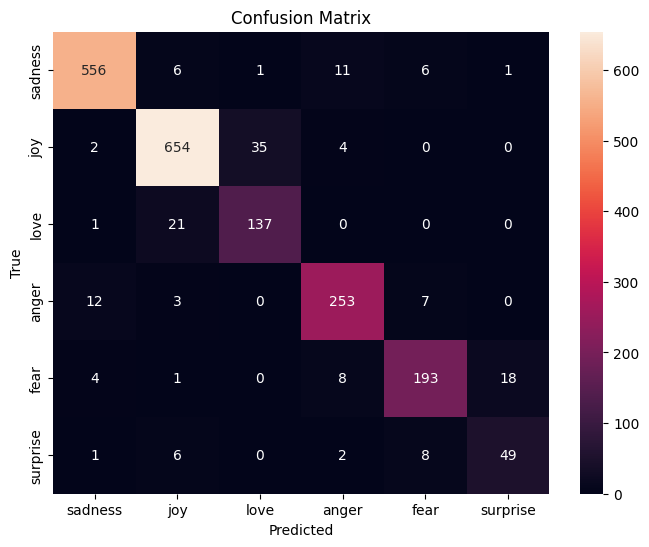

In [25]:
import os
cm = confusion_matrix(y_true, y_pred)

ARTIFACTS_DIR = "artifacts"
os.makedirs(ARTIFACTS_DIR, exist_ok=True)


plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", xticklabels=labels, yticklabels=labels)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.savefig(os.path.join(ARTIFACTS_DIR, "confusion_matrix.png"))
plt.show()

In [26]:
texts = dataset["test"]["text"]

df = pd.DataFrame({
    "text": texts,
    "true_label": [labels[i] for i in y_true],
    "pred_label": [labels[i] for i in y_pred]
})

df["confidence"] = np.max(
    torch.softmax(torch.tensor(predictions.predictions), dim=1).numpy(),
    axis=1
)

In [27]:
df.head(10)

,text,true_label,pred_label,confidence
0,im feeling rather rotten so im not very ambiti...,sadness,sadness,0.990565
1,im updating my blog because i feel shitty,sadness,sadness,0.994138
2,i never make her separate from me because i do...,sadness,sadness,0.993672
3,i left with my bouquet of red and yellow tulip...,joy,joy,0.988955
4,i was feeling a little vain when i did this one,sadness,sadness,0.992159
5,i cant walk into a shop anywhere where i do no...,fear,fear,0.960757
6,i felt anger when at the end of a telephone call,anger,anger,0.980904
7,i explain why i clung to a relationship with a...,joy,joy,0.973965
8,i like to have the same breathless feeling as ...,joy,joy,0.981580
9,i jest i feel grumpy tired and pre menstrual w...,anger,anger,0.979910


In [28]:
errors = df[df["true_label"] != df["pred_label"]]
errors.head(10)

,text,true_label,pred_label,confidence
10,i don t feel particularly agitated,fear,anger,0.489571
67,i feel a bit stressed even though all the thin...,anger,sadness,0.856862
93,i was feeling weird the other day and it went ...,fear,surprise,0.493609
98,i feel my heart is tortured by what i have done,anger,fear,0.784980
103,i feel agitated with myself that i did not for...,fear,anger,0.577045
108,i looked at mabel this morning i named my left...,fear,surprise,0.722677
125,i feel very mislead by someone that i really r...,love,sadness,0.934315
150,im feeling rather angsty and listless,sadness,love,0.552850
193,i really dont like quinn because i feel like s...,anger,sadness,0.964488
234,i love to dance but often feel inhibited by my...,fear,sadness,0.974710


Видно, что модель путает близкие эмоции. Например fear и anger, которые выражают напряжение

In [ ]:
df.head(100).to_csv(os.path.join(ARTIFACTS_DIR / "sample_predictions.csv"), index=False)